In [1]:
# Run this in Jupyter to auto-download the Telco dataset
import urllib.request

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
urllib.request.urlretrieve(url, "telco_churn.csv")
print("Dataset downloaded!")

Dataset downloaded!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("telco_churn.csv")

print("Shape:", df.shape)        # rows x columns
print("\nColumns:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

Columns:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Check data types and nulls
df.info()

# Statistical summary
df.describe()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check target column
print("\nChurn distribution:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# TotalCharges has a hidden issue — it's stored as string, not number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# This creates NaN for blank values — fill with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Drop customerID — it's just an ID, not useful for prediction
df.drop('customerID', axis=1, inplace=True)

# Convert target: Yes → 1, No → 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Cleaning done!")
print(df.shape)
df.head()

Cleaning done!
(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


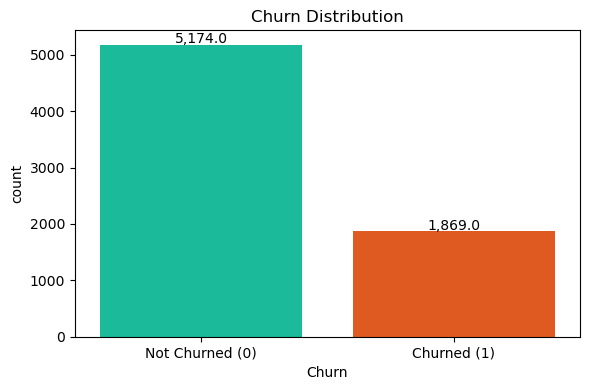

In [5]:
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='Churn', palette=['#00d4aa','#ff4d00'])
ax.set_xticklabels(['Not Churned (0)', 'Churned (1)'])
plt.title('Churn Distribution')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x()+p.get_width()/2, p.get_height()+30), ha='center')
plt.tight_layout()
plt.savefig('churn_distribution.png')
plt.show()

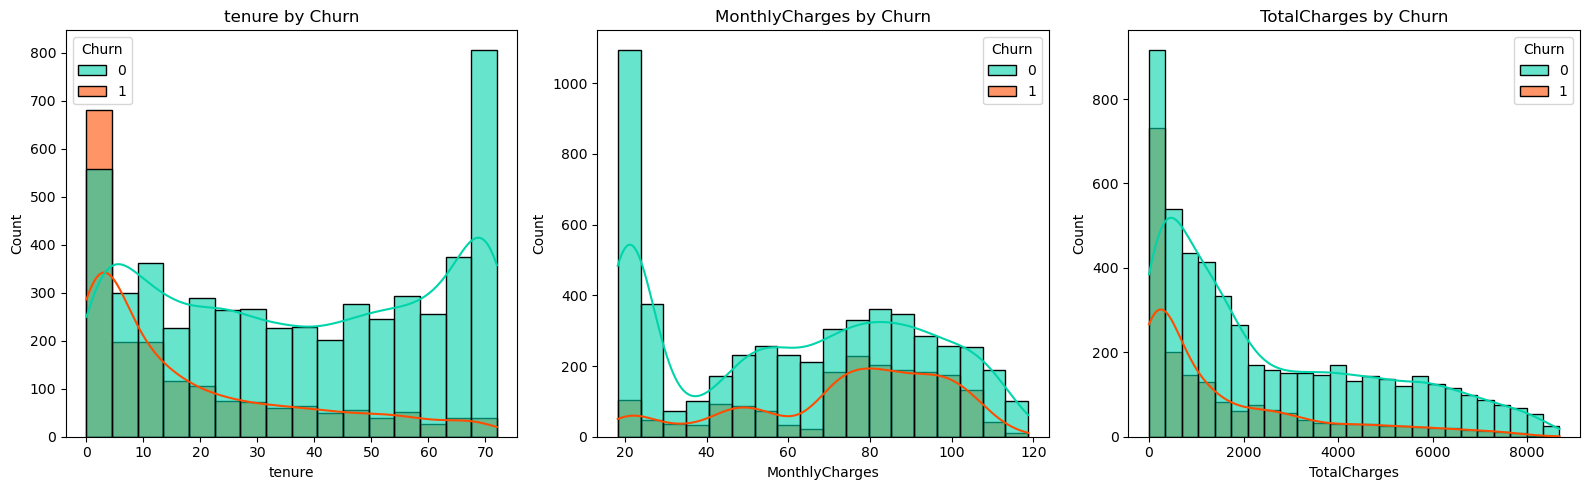

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(data=df, x=col, hue='Churn', kde=True,
                 palette={0:'#00d4aa', 1:'#ff4d00'}, ax=ax, alpha=0.6)
    ax.set_title(f'{col} by Churn')

plt.tight_layout()
plt.savefig('numeric_features.png')
plt.show()

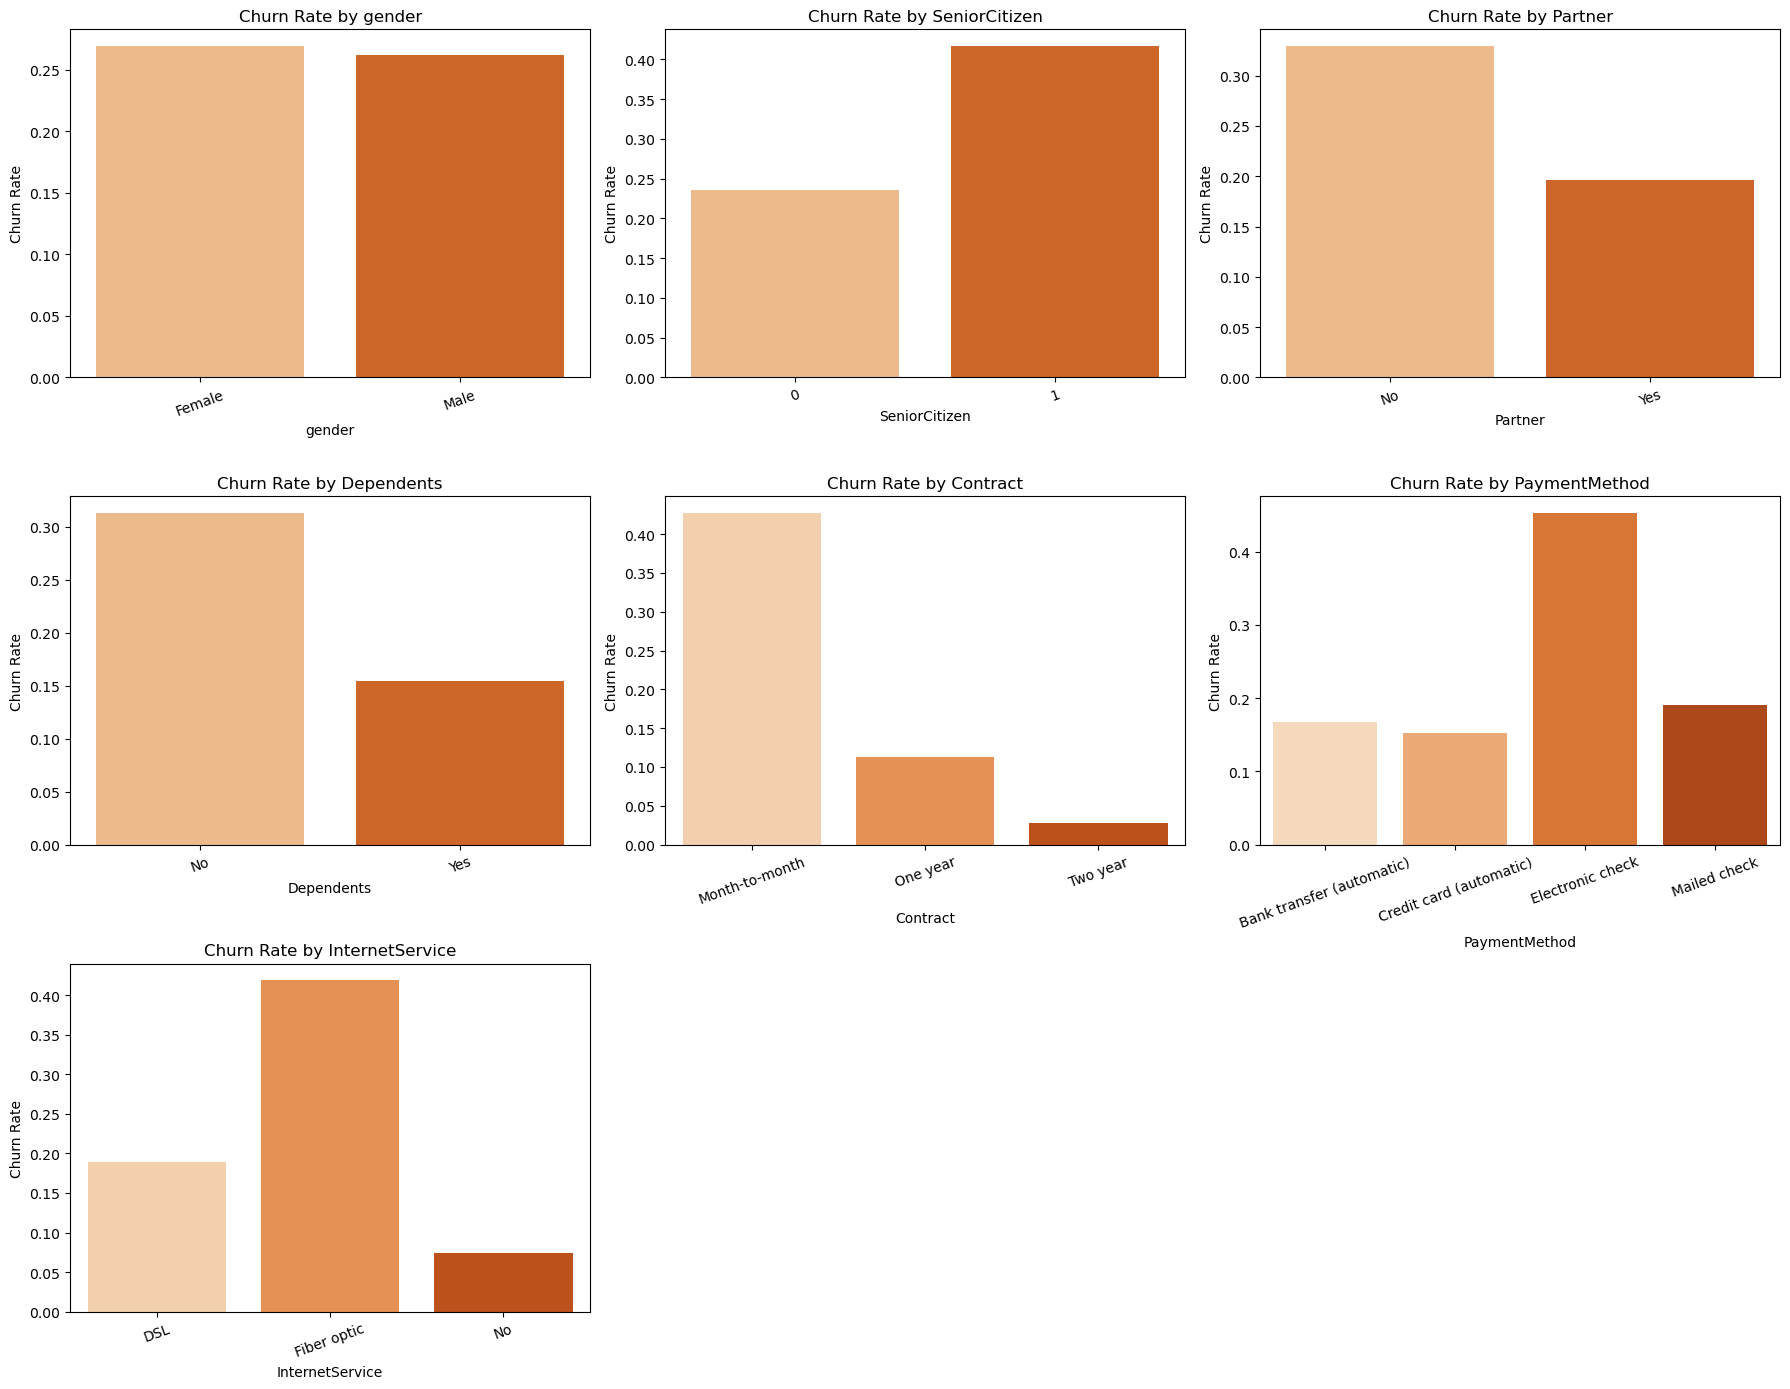

In [7]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'Contract', 'PaymentMethod', 'InternetService']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().reset_index()
    sns.barplot(data=churn_rate, x=col, y='Churn',
                palette='Oranges', ax=axes[i])
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].tick_params(axis='x', rotation=20)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('categorical_features.png')
plt.show()

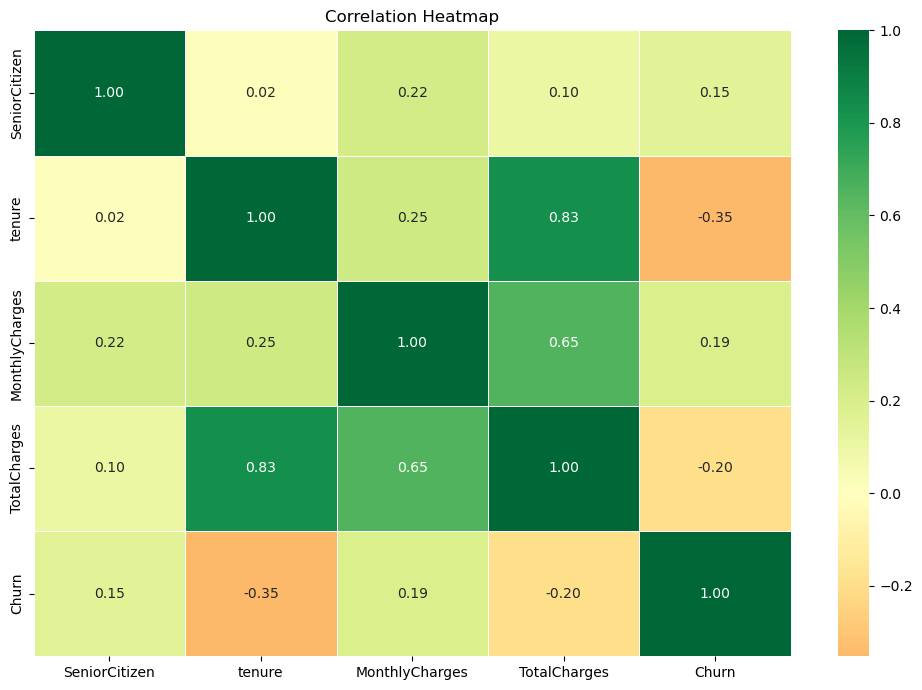

In [8]:
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

In [9]:
# ML models only understand numbers — convert text columns to numbers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Find all text (object) columns
cat_cols = df.select_dtypes(include='object').columns
print("Encoding columns:", list(cat_cols))

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Encoding done!")
df.head()

Encoding columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Encoding done!


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [10]:
X = df.drop('Churn', axis=1)   # All columns EXCEPT Churn
y = df['Churn']                 # Just the Churn column

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nChurn balance:")
print(y.value_counts())

X shape: (7043, 19)
y shape: (7043,)

Churn balance:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% for testing
    random_state=42,        # for reproducibility
    stratify=y              # keeps same churn % in both splits
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5634, 19)
Test size: (1409, 19)


In [12]:
# Scaling brings all numbers to same range — very important for ML
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)       # IMPORTANT: only transform, don't fit again

print("Scaling done!")

Scaling done!


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score)

models = {
    'Logistic Regression':    LogisticRegression(random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    roc    = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    results[name] = {'Accuracy': round(acc*100, 2), 'ROC-AUC': round(roc, 4)}
    print(f"\n{'='*40}")
    print(f" {name}")
    print(f"{'='*40}")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  ROC-AUC  : {roc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['No Churn','Churn']))


 Logistic Regression
  Accuracy : 79.84%
  ROC-AUC  : 0.8404
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


 Random Forest
  Accuracy : 79.56%
  ROC-AUC  : 0.8253
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.64      0.52      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


 Gradient Boosting
  Accuracy : 80.77%
  ROC-AUC  : 0.8441
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.68      0.52      0.59       374

    

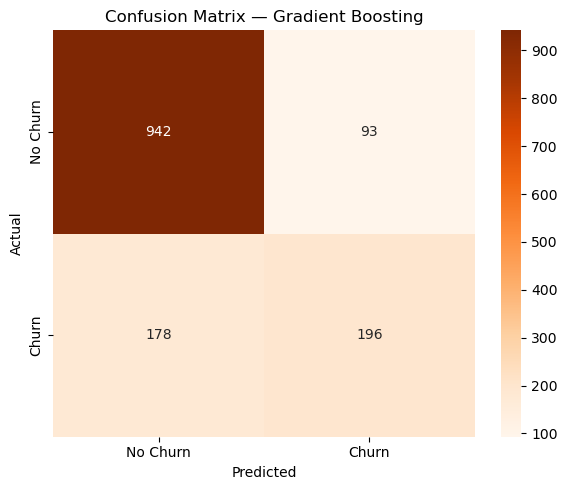

In [14]:
# Gradient Boosting is usually the best — let's visualize it
best_model = models['Gradient Boosting']
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
plt.title('Confusion Matrix — Gradient Boosting')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

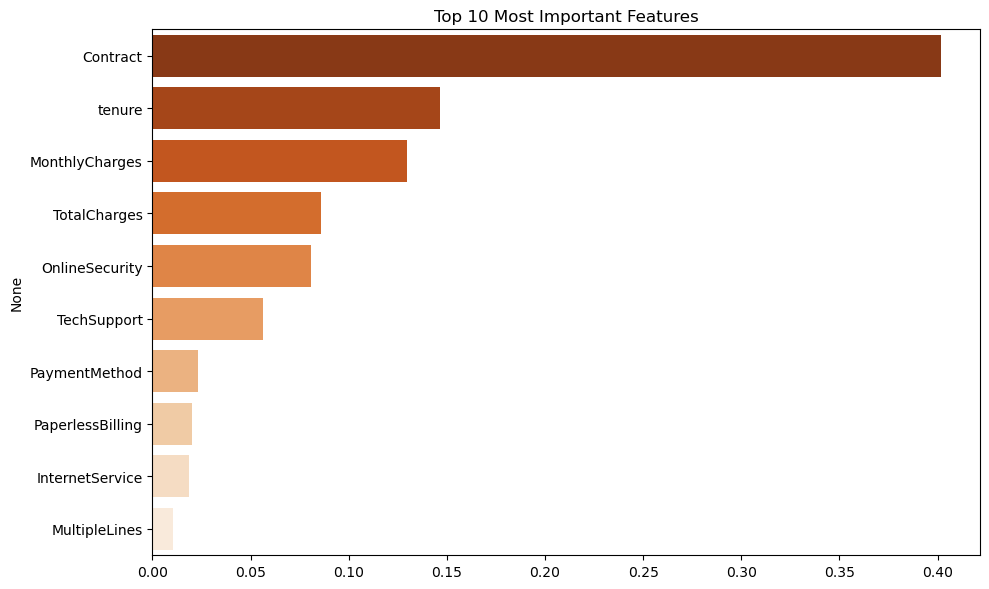

In [15]:
feat_imp = pd.Series(best_model.feature_importances_,
                     index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values[:10], y=feat_imp.index[:10], palette='Oranges_r')
plt.title('Top 10 Most Important Features')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [16]:
import joblib

joblib.dump(best_model, 'churn_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')

print("Model saved! ✅")

Model saved! ✅


In [17]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# ── Load saved model & scaler ──
model    = joblib.load('churn_model.pkl')
scaler   = joblib.load('scaler.pkl')
features = joblib.load('feature_names.pkl')

# ── Page Config ──
st.set_page_config(
    page_title="Customer Churn Predictor",
    page_icon="🔄",
    layout="wide"
)

# ── Header ──
st.title("🔄 Customer Churn Predictor")
st.markdown("Fill in the customer details below to predict whether they will **churn or stay**.")
st.divider()

# ── Input Form ──
col1, col2, col3 = st.columns(3)

with col1:
    st.subheader("👤 Demographics")
    gender         = st.selectbox("Gender", ["Male", "Female"])
    senior         = st.selectbox("Senior Citizen", ["No", "Yes"])
    partner        = st.selectbox("Has Partner?", ["Yes", "No"])
    dependents     = st.selectbox("Has Dependents?", ["Yes", "No"])

with col2:
    st.subheader("📱 Services")
    phone_service  = st.selectbox("Phone Service", ["Yes", "No"])
    multiple_lines = st.selectbox("Multiple Lines", ["No", "Yes", "No phone service"])
    internet       = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
    online_sec     = st.selectbox("Online Security", ["Yes", "No", "No internet service"])
    online_backup  = st.selectbox("Online Backup", ["Yes", "No", "No internet service"])
    device_prot    = st.selectbox("Device Protection", ["Yes", "No", "No internet service"])
    tech_support   = st.selectbox("Tech Support", ["Yes", "No", "No internet service"])
    streaming_tv   = st.selectbox("Streaming TV", ["Yes", "No", "No internet service"])
    streaming_mov  = st.selectbox("Streaming Movies", ["Yes", "No", "No internet service"])

with col3:
    st.subheader("💳 Account Info")
    tenure         = st.slider("Tenure (months)", 0, 72, 12)
    contract       = st.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
    paperless      = st.selectbox("Paperless Billing", ["Yes", "No"])
    payment        = st.selectbox("Payment Method", [
                        "Electronic check", "Mailed check",
                        "Bank transfer (automatic)", "Credit card (automatic)"])
    monthly        = st.number_input("Monthly Charges ($)", 0.0, 200.0, 65.0)
    total          = st.number_input("Total Charges ($)", 0.0, 10000.0, float(tenure * monthly))

st.divider()

# ── Predict Button ──
if st.button("🔮 Predict Churn", use_container_width=True, type="primary"):

    # Encode inputs same way as training
    encode = {
        'Yes': 1, 'No': 0,
        'Male': 1, 'Female': 0,
        'Month-to-month': 0, 'One year': 1, 'Two year': 2,
        'DSL': 0, 'Fiber optic': 1, 'No': 0,
        'Electronic check': 0, 'Mailed check': 1,
        'Bank transfer (automatic)': 2, 'Credit card (automatic)': 3,
        'No phone service': 2, 'No internet service': 2
    }

    def enc(val):
        return encode.get(val, 0)

    input_data = pd.DataFrame([[
        enc(gender), enc(senior), enc(partner), enc(dependents),
        tenure, enc(phone_service), enc(multiple_lines),
        enc(internet), enc(online_sec), enc(online_backup),
        enc(device_prot), enc(tech_support), enc(streaming_tv),
        enc(streaming_mov), enc(contract), enc(paperless),
        enc(payment), monthly, total
    ]], columns=features)

    input_scaled = scaler.transform(input_data)
    prediction   = model.predict(input_scaled)[0]
    probability  = model.predict_proba(input_scaled)[0][1]

    st.subheader("📊 Prediction Result")
    res_col1, res_col2 = st.columns(2)

    with res_col1:
        if prediction == 1:
            st.error(f"⚠️ This customer is **LIKELY TO CHURN**")
        else:
            st.success(f"✅ This customer is **LIKELY TO STAY**")

    with res_col2:
        st.metric("Churn Probability", f"{probability*100:.1f}%")
        st.progress(float(probability))

    # Risk level
    if probability >= 0.7:
        st.warning("🔴 **High Risk** — Immediate action recommended!")
    elif probability >= 0.4:
        st.warning("🟡 **Medium Risk** — Monitor this customer closely.")
    else:
        st.info("🟢 **Low Risk** — Customer looks stable.")

2026-04-05 22:11:50.022 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 22:11:50.022 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 22:11:50.159 
  command:

    streamlit run /opt/anaconda3/lib/python3.13/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-04-05 22:11:50.159 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 22:11:50.160 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 22:11:50.160 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 22:11:50.161 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when run

In [20]:
import os
print(os.getcwd())

/Users/shruthig
